<a href="https://www.kaggle.com/code/sonawanelalitsunil/heart-disease-risk-analysis-ml-86-89?scriptVersionId=229926929" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-disease-dataset/heart.csv


## Title: Heart Disease Risk Analysis

## Description: An in-depth study of heart disease risk factors, patient demographics, and predictive modeling for early diagnosis. ❤️📊

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/heart-disease-dataset/heart.csv')

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
df.duplicated().sum()

1

In [9]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [10]:
df.shape

(303, 14)

In [11]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

## Data visualizations

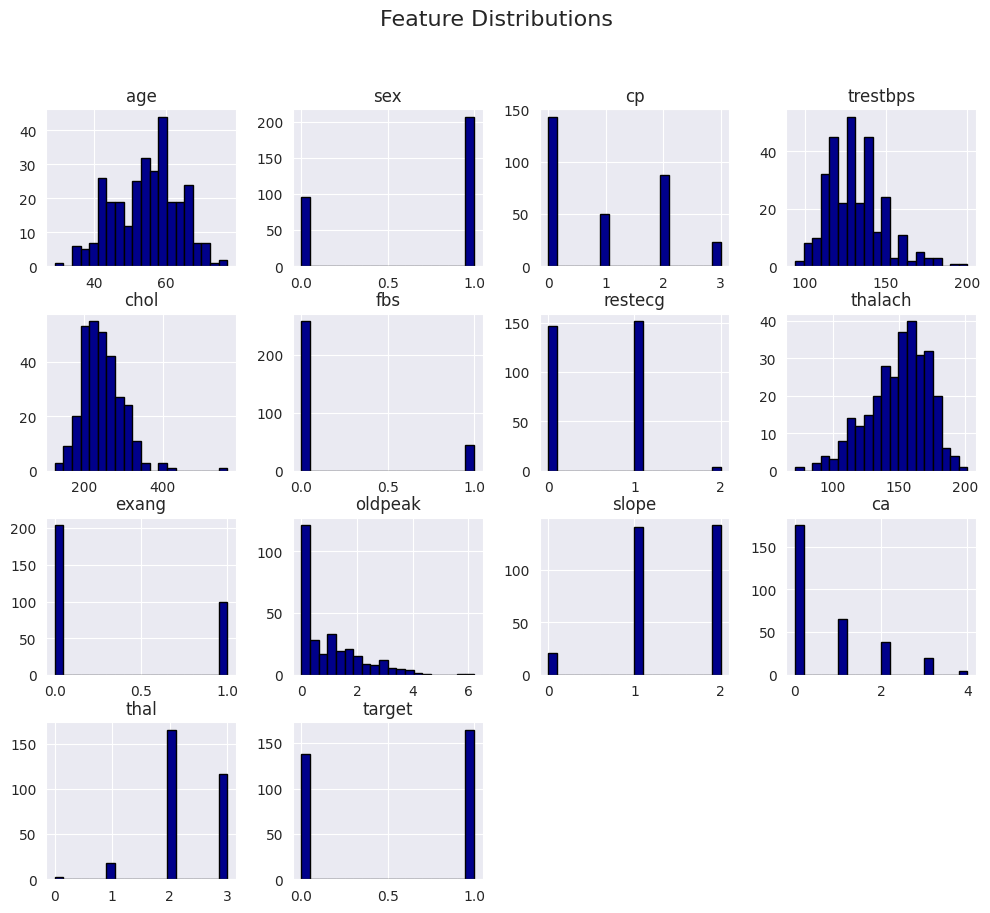

In [12]:
sns.set_style("darkgrid")

# 1️⃣ **Feature Distributions (Histograms)**
df.hist(figsize=(12, 10), bins=20, color="darkblue", edgecolor="black")
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

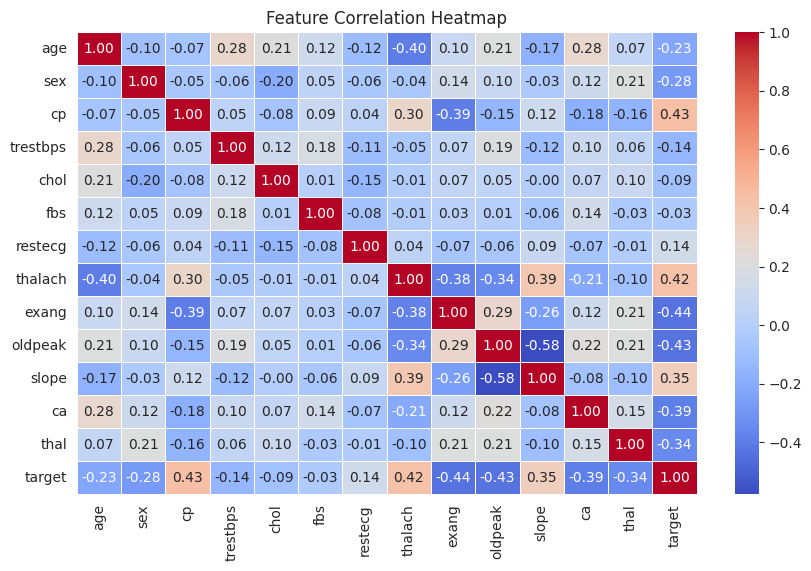

In [13]:
# 2️⃣ **Correlation Heatmap**
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

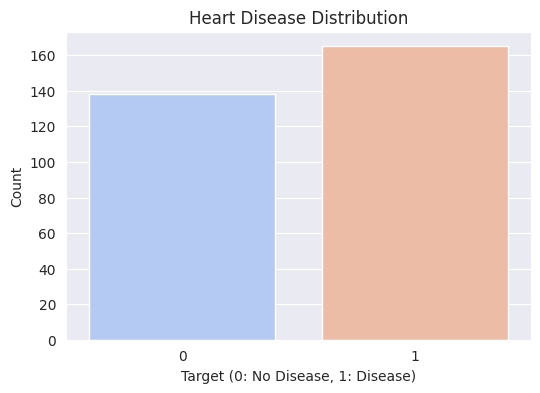

In [14]:
# 3️⃣ **Target Variable Distribution**
plt.figure(figsize=(6, 4))
sns.countplot(x=df["target"], palette="coolwarm")
plt.title("Heart Disease Distribution")
plt.xlabel("Target (0: No Disease, 1: Disease)")
plt.ylabel("Count")
plt.show()

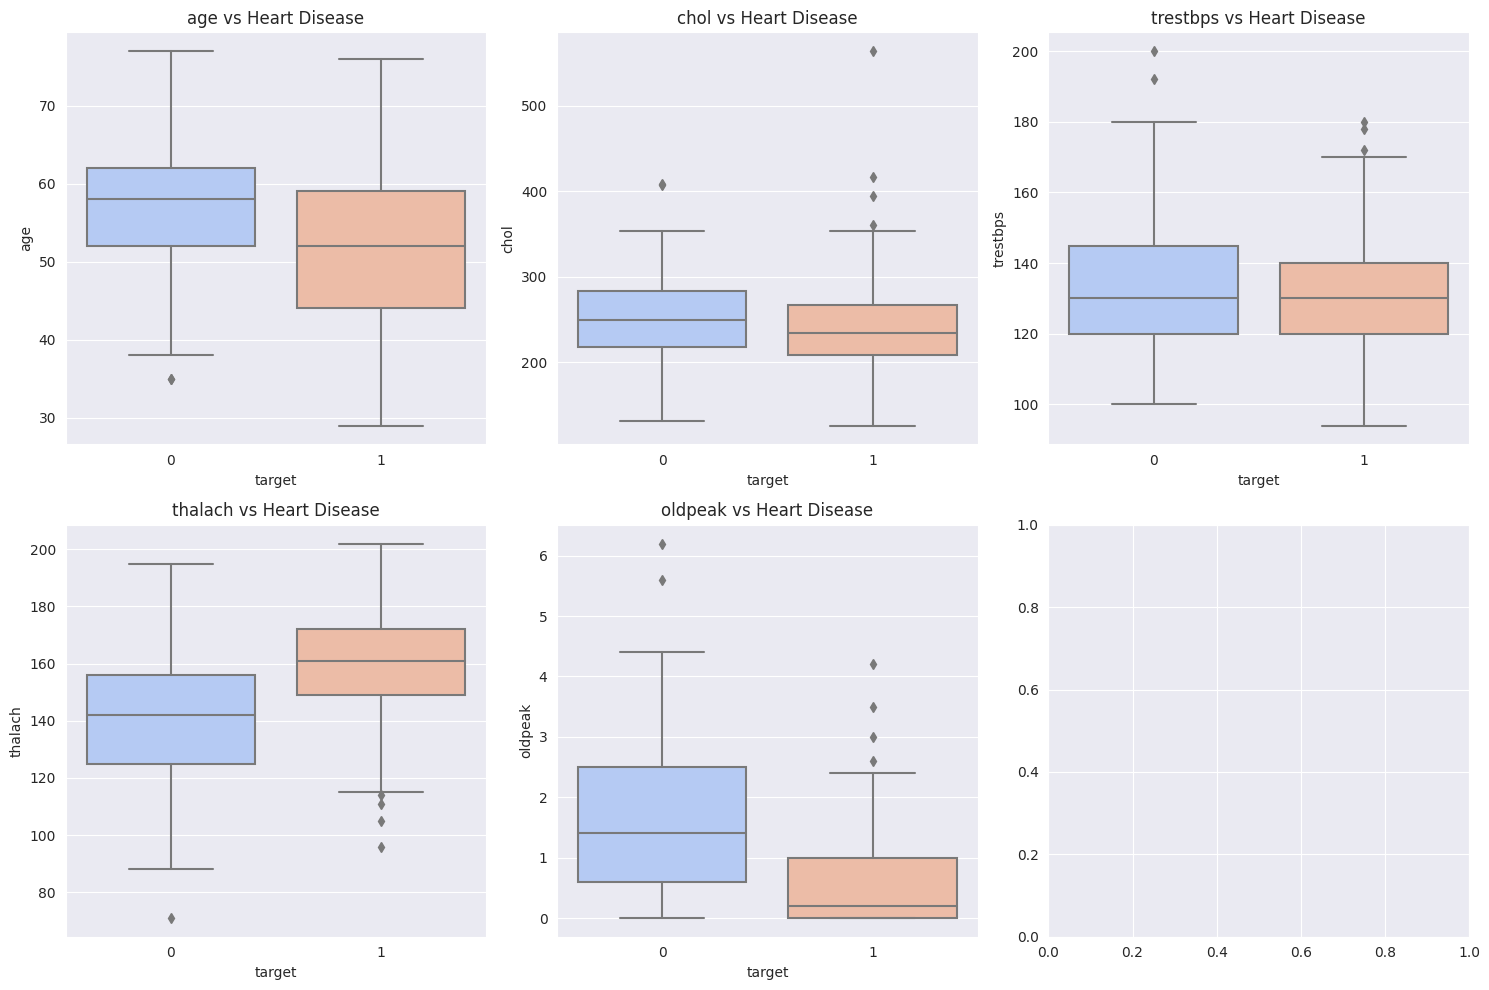

In [15]:
# 4️⃣ **Boxplots to Compare Features with Target**
features_to_compare = ['age', 'chol', 'trestbps', 'thalach', 'oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, col in enumerate(features_to_compare):
    row, col_idx = divmod(idx, 3)
    sns.boxplot(x=df["target"], y=df[col], ax=axes[row, col_idx], palette="coolwarm")
    axes[row, col_idx].set_title(f"{col} vs Heart Disease")

plt.tight_layout()
plt.show()

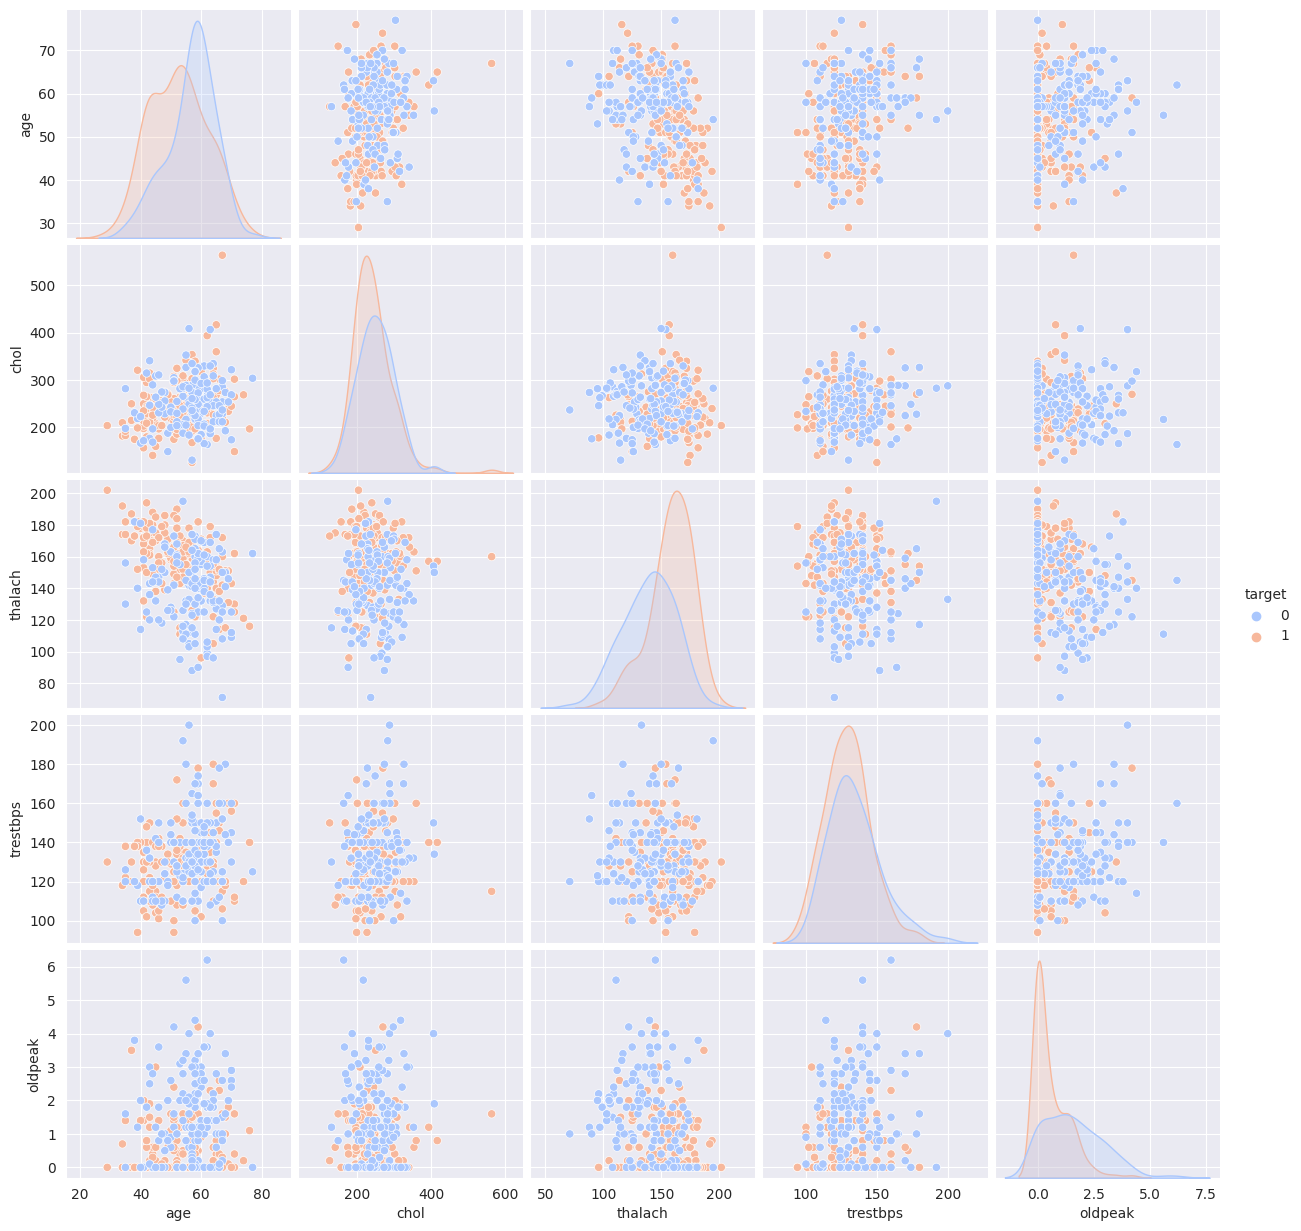

In [16]:
# 5️⃣ **Pairwise Relationship (Scatterplots)**
sns.pairplot(df[['age', 'chol', 'thalach', 'trestbps', 'oldpeak', 'target']], hue="target", palette="coolwarm")
plt.show()


## Predictive Modeling

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [18]:
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

In [19]:
label_encoders = {}
for col in categorical_cols:
    label_encoders[col] = LabelEncoder()
    df[col] = label_encoders[col].fit_transform(df[col])


In [20]:
X = df.drop(columns=['target'])  # Features
y = df['target']

In [21]:
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(kernel='rbf'),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

In [24]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)  # Train model
    y_pred = model.predict(X_test)  # Make predictions
    accuracy = accuracy_score(y_test, y_pred) * 100  # Convert to percentage
    results[name] = round(accuracy, 2)

In [25]:
print("\nModel Accuracy Results (%):")
for model, score in results.items():
    print(f"{model}: {score}%")


Model Accuracy Results (%):
Logistic Regression: 85.25%
Random Forest: 83.61%
Gradient Boosting: 78.69%
Support Vector Machine: 86.89%
K-Nearest Neighbors: 86.89%
Decision Tree: 75.41%


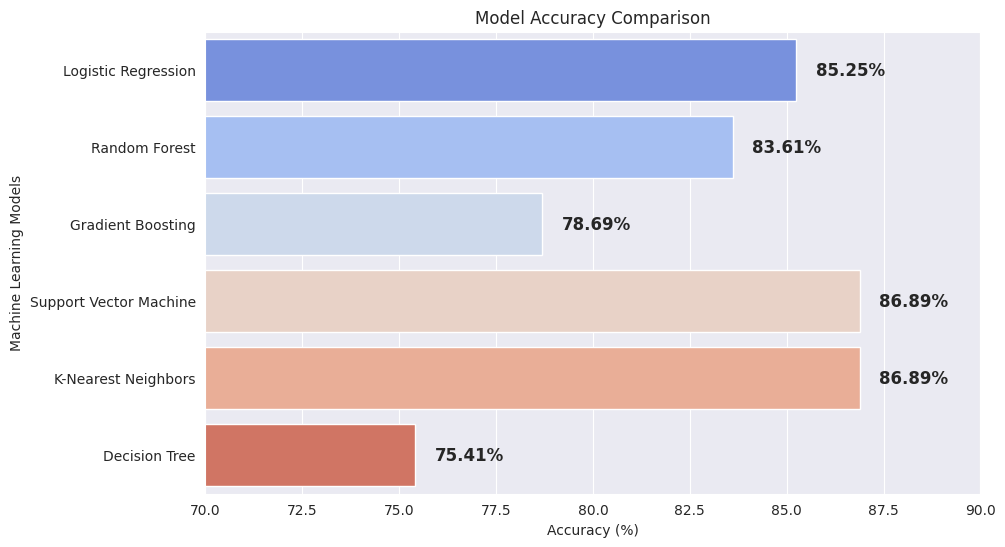

In [26]:
# Model performance data
model_names = ["Logistic Regression", "Random Forest", "Gradient Boosting", 
               "Support Vector Machine", "K-Nearest Neighbors", "Decision Tree"]
accuracy_scores = [85.25, 83.61, 78.69, 86.89, 86.89, 75.41]

# Set plot style
sns.set_style("darkgrid")
plt.figure(figsize=(10, 6))

# Create barplot
sns.barplot(x=accuracy_scores, y=model_names, palette="coolwarm")

# Add titles and labels
plt.xlabel("Accuracy (%)")
plt.ylabel("Machine Learning Models")
plt.title("Model Accuracy Comparison")

# Show values on bars
for index, value in enumerate(accuracy_scores):
    plt.text(value + 0.5, index, f"{value}%", va='center', fontsize=12, fontweight='bold')

# Show plot
plt.xlim(70, 90)  # Adjust x-axis limit for better readability
plt.show()

## Thank you...pls upvote!!!!